#  MPS Classification Experiments (TorchMPS)

TorchMPS was used for all experiments [Miller, 2019].
https://github.com/jemisjoky/torchmps

## Experiment Overview

- Goal: Compare performance of Matrix Product State (MPS) models under different feature-map configurations.
- Datasets:
  - MNIST
  - FashionMNIST
- Input preprocessing:
  - Images resized from 28×28 → 14×14
  - Flattened into vectors of size 196
- Output: 10-class classification


## TorchMPS Model Details

- TorchMPS is a PyTorch-based implementation of Matrix Product State (MPS) models for machine learning.
- It represents inputs as a chain of local feature vectors and contracts them through a tensor network.

### Key parameters used:

Number of training data was 1000 and test data 500 throughout the experiments
- `input_dim`: Number of input sites (196)
- `output_dim`: Number of classes (10)
- `bond_dim`: Controls model capacity (higher = more expressive)
- `feature_dim`: Size of local feature embedding
- `adaptive_mode=False`: Fixed bond dimension
- `periodic_bc=False`: Open boundary MPS

TorchMPS allows custom feature maps via:

```python
mps.register_feature_map(feature_map)




# Imports

In [48]:
import time
import math
import random
import copy

import torch
import matplotlib.pyplot as plt

from torchmps import MPS
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, SubsetRandomSampler

# parameters

In [49]:
# Reproducibility
SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data parameters
image_size = 14
num_train = 1000
num_test = 500
batch_size = 100

# Training parameters
num_epochs = 20
learn_rate = 1e-4
l2_reg = 0.0

# MPS options shared across experiments
adaptive_mode = False
periodic_bc = False

# Dataset root
data_root = "./data"

Using device: cpu


# Feature maps

In [50]:
def feature_map_2d(x):
    """
        apply 2d feature map to input
    """
    return torch.stack([
        torch.cos(math.pi * x / 2),
        torch.sin(math.pi * x / 2),
    ], dim=-1)

def feature_map_4d(x):

    """
        apply 2d feature map to input
    """
    return torch.stack([
        torch.cos(math.pi * x / 2),
        torch.sin(math.pi * x / 2),
        torch.cos(3 * math.pi * x / 2),
        torch.sin(3 * math.pi * x / 2),
    ], dim=-1)

# Dataset loader

In [51]:
def get_dataloaders(dataset_name, num_train, num_test, batch_size, image_size, seed=0):

    """
    Create training and test DataLoaders for MNIST or FashionMNIST.
    """
    #Resize images
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])

    #Load dataset
    if dataset_name.lower() == "mnist":
        train_set = datasets.MNIST(data_root, train=True, download=True, transform=transform)
        test_set = datasets.MNIST(data_root, train=False, download=True, transform=transform)
    elif dataset_name.lower() == "fashionmnist":
        train_set = datasets.FashionMNIST(data_root, train=True, download=True, transform=transform)
        test_set = datasets.FashionMNIST(data_root, train=False, download=True, transform=transform)

    g = torch.Generator()
    g.manual_seed(seed)

    #sample a subset of indices for training and testing
    train_indices = torch.randperm(len(train_set), generator=g)[:num_train].tolist()
    test_indices = torch.randperm(len(test_set), generator=g)[:num_test].tolist()

    # Create DataLoader for training set
    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        sampler=SubsetRandomSampler(train_indices),
        drop_last=True,
    )

    # Create DataLoader for test set
    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        sampler=SubsetRandomSampler(test_indices),
        drop_last=True,
    )

    return train_loader, test_loader

# MPS model

In [52]:
def build_mps_experiment(input_dim, output_dim, bond_dim, feature_dim=None, feature_map=None):
    """
    Build a TorchMPS model for a given experiment configuration.
    """
    # If no feature map use default behavior
    if feature_map is None:
        mps = MPS(
            input_dim=input_dim,
            output_dim=output_dim,
            bond_dim=bond_dim,
            adaptive_mode=adaptive_mode,
            periodic_bc=periodic_bc,
        )
    else:
        mps = MPS(
            input_dim=input_dim,
            output_dim=output_dim,
            bond_dim=bond_dim,
            feature_dim=feature_dim,
            adaptive_mode=adaptive_mode,
            periodic_bc=periodic_bc,
        )
        mps.register_feature_map(feature_map)

    return mps.to(device)

# Utility

In [53]:
def evaluate_model(model, loader, loss_fun, input_dim):
    """
        Usual pytorch training loop
    """
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    num_batches = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.view(inputs.size(0), input_dim).to(device)
            labels = labels.to(device)

            scores = model(inputs)
            loss = loss_fun(scores, labels)
            preds = torch.argmax(scores, dim=1)

            acc = (preds == labels).float().mean().item()

            running_loss += loss.item()
            running_acc += acc
            num_batches += 1

    return running_loss / num_batches, running_acc / num_batches


def train_one_experiment(dataset_name, exp_name, bond_dim, feature_dim=None, feature_map=None):
    print(f"\n===== {dataset_name} | {exp_name} =====")

    input_dim = image_size ** 2
    output_dim = 10

    train_loader, test_loader = get_dataloaders(
        dataset_name=dataset_name,
        num_train=num_train,
        num_test=num_test,
        batch_size=batch_size,
        image_size=image_size,
        seed=SEED,
    )

    model = build_mps_experiment(
        input_dim=input_dim,
        output_dim=output_dim,
        bond_dim=bond_dim,
        feature_dim=feature_dim,
        feature_map=feature_map,
    )

    loss_fun = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learn_rate, weight_decay=l2_reg)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        running_acc = 0.0
        num_batches = 0

        for inputs, labels in train_loader:
            inputs = inputs.view(inputs.size(0), input_dim).to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            scores = model(inputs)
            loss = loss_fun(scores, labels)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                preds = torch.argmax(scores, dim=1)
                acc = (preds == labels).float().mean().item()

            running_loss += loss.item()
            running_acc += acc
            num_batches += 1

        train_loss = running_loss / num_batches
        train_acc = running_acc / num_batches

        test_loss, test_acc = evaluate_model(model, test_loader, loss_fun, input_dim)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
            f"test loss: {test_loss:.4f}, test acc: {test_acc:.4f}"
        )

    runtime = time.time() - start_time
    print(f"Runtime: {runtime:.1f} sec")

    return model, history

# Plotting

In [61]:
def plot_history(history, title_prefix=""):
    """
    Training/Test loss/acc vs epoch
    
    """
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["test_acc"], label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.grid(True)

    # Loss (error)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Experiments

In [63]:
""" Prameters of the different experiment to be run """

experiments = [
    {
        "name": "no_feature_map_bond20",
        "bond_dim": 20,
        "feature_dim": None,
        "feature_map": None,
    },
    {
        "name": "feature_map_2d_bond10",
        "bond_dim": 10,
        "feature_dim": 2,
        "feature_map": feature_map_2d,
    },
    {
        "name": "feature_map_2d_bond20",
        "bond_dim": 20,
        "feature_dim": 2,
        "feature_map": feature_map_2d,
    },
    {
        "name": "feature_map_4d_bond20",
        "bond_dim": 20,
        "feature_dim": 4,
        "feature_map": feature_map_4d,
    },
]

# MNIST experiments


===== mnist | no_feature_map_bond20 =====


C:\Users\Asus\mlp\Lib\site-packages\torchmps\utils.py:244: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:353.)
  tensor[[slice(dim) for dim in expand_shape]] = eye_tensor


Epoch 01/20 | train loss: 2.3026, train acc: 0.1110 | test loss: 2.3025, test acc: 0.1020
Epoch 02/20 | train loss: 2.2900, train acc: 0.1240 | test loss: 2.3516, test acc: 0.1020
Epoch 03/20 | train loss: 2.2769, train acc: 0.1240 | test loss: 2.2747, test acc: 0.1020
Epoch 04/20 | train loss: 2.2402, train acc: 0.1240 | test loss: 2.2344, test acc: 0.1020
Epoch 05/20 | train loss: 2.1976, train acc: 0.1240 | test loss: 2.1857, test acc: 0.1020
Epoch 06/20 | train loss: 2.1344, train acc: 0.1240 | test loss: 2.1435, test acc: 0.1020
Epoch 07/20 | train loss: 2.0709, train acc: 0.1730 | test loss: 2.0066, test acc: 0.2980
Epoch 08/20 | train loss: 1.8658, train acc: 0.3630 | test loss: 1.8319, test acc: 0.3320
Epoch 09/20 | train loss: 1.8380, train acc: 0.3650 | test loss: 1.8524, test acc: 0.3980
Epoch 10/20 | train loss: 1.7007, train acc: 0.4050 | test loss: 1.6778, test acc: 0.4180
Epoch 11/20 | train loss: 1.4743, train acc: 0.4520 | test loss: 1.4629, test acc: 0.4720
Epoch 12/2

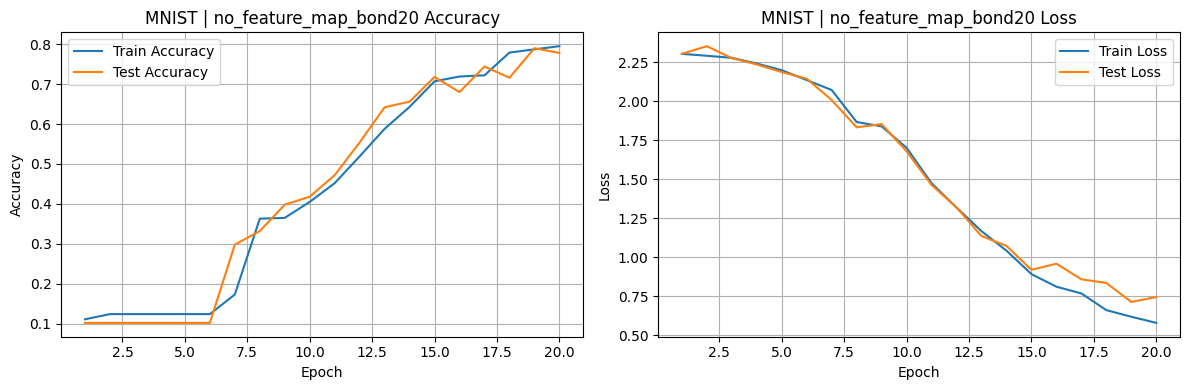


===== mnist | feature_map_2d_bond10 =====
Epoch 01/20 | train loss: 2.3026, train acc: 0.0940 | test loss: 2.3026, test acc: 0.1200
Epoch 02/20 | train loss: 2.3022, train acc: 0.1170 | test loss: 2.3015, test acc: 0.1020
Epoch 03/20 | train loss: 2.2929, train acc: 0.1240 | test loss: 2.2978, test acc: 0.1020
Epoch 04/20 | train loss: 2.2630, train acc: 0.1240 | test loss: 2.2697, test acc: 0.1020
Epoch 05/20 | train loss: 2.2293, train acc: 0.1240 | test loss: 2.2368, test acc: 0.1020
Epoch 06/20 | train loss: 2.1846, train acc: 0.1240 | test loss: 2.1906, test acc: 0.1020
Epoch 07/20 | train loss: 2.1135, train acc: 0.1530 | test loss: 2.0550, test acc: 0.2440
Epoch 08/20 | train loss: 1.8254, train acc: 0.3380 | test loss: 1.6483, test acc: 0.3900
Epoch 09/20 | train loss: 1.5862, train acc: 0.4070 | test loss: 1.5733, test acc: 0.4620
Epoch 10/20 | train loss: 1.4204, train acc: 0.4900 | test loss: 1.4816, test acc: 0.4860
Epoch 11/20 | train loss: 1.3327, train acc: 0.5330 | tes

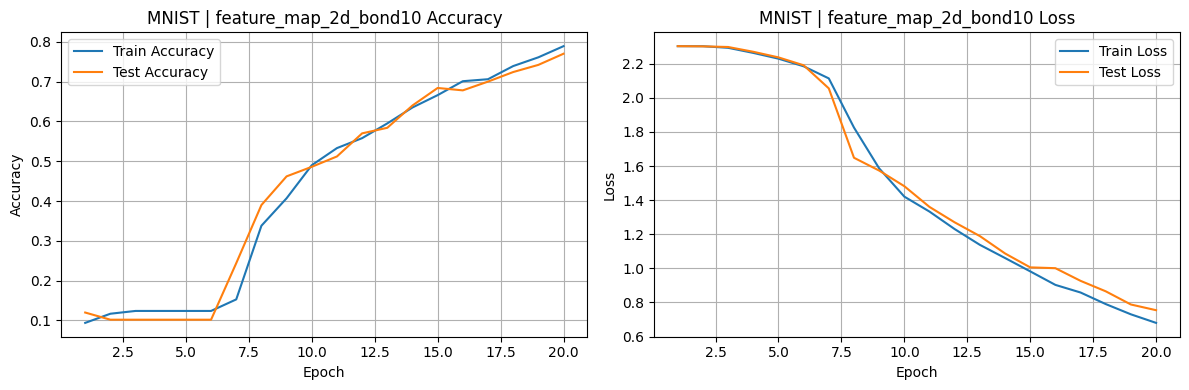


===== mnist | feature_map_2d_bond20 =====
Epoch 01/20 | train loss: 2.3025, train acc: 0.1110 | test loss: 2.3024, test acc: 0.1020
Epoch 02/20 | train loss: 2.2947, train acc: 0.1240 | test loss: 2.3019, test acc: 0.1020
Epoch 03/20 | train loss: 2.2618, train acc: 0.1240 | test loss: 2.2632, test acc: 0.1020
Epoch 04/20 | train loss: 2.2159, train acc: 0.1240 | test loss: 2.2533, test acc: 0.1020
Epoch 05/20 | train loss: 2.1724, train acc: 0.1240 | test loss: 2.1680, test acc: 0.1020
Epoch 06/20 | train loss: 2.1212, train acc: 0.1240 | test loss: 2.1518, test acc: 0.1020
Epoch 07/20 | train loss: 2.0982, train acc: 0.1250 | test loss: 2.1126, test acc: 0.1020
Epoch 08/20 | train loss: 2.0543, train acc: 0.1620 | test loss: 2.0504, test acc: 0.1920
Epoch 09/20 | train loss: 1.9654, train acc: 0.2860 | test loss: 1.9105, test acc: 0.2880
Epoch 10/20 | train loss: 1.8221, train acc: 0.3670 | test loss: 1.8231, test acc: 0.3820
Epoch 11/20 | train loss: 1.7148, train acc: 0.4080 | tes

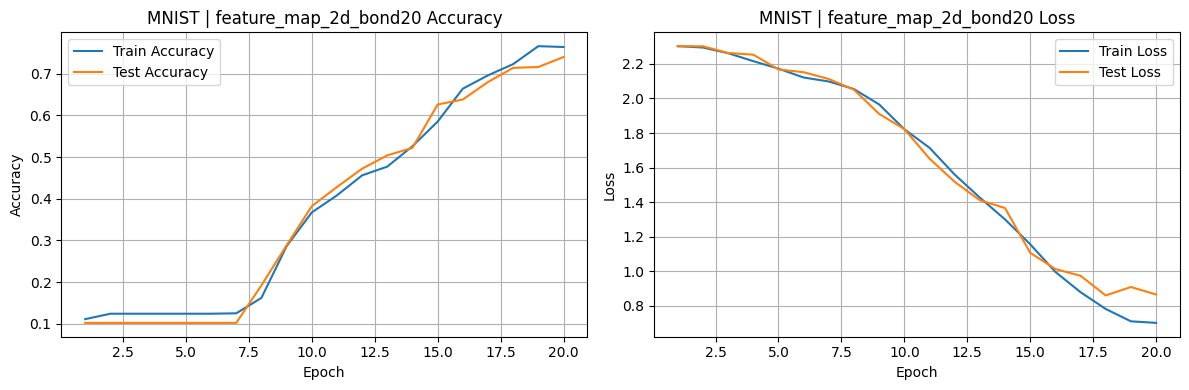


===== mnist | feature_map_4d_bond20 =====
Epoch 01/20 | train loss: 2.3025, train acc: 0.1220 | test loss: 2.3023, test acc: 0.1400
Epoch 02/20 | train loss: 2.2751, train acc: 0.1310 | test loss: 2.2021, test acc: 0.1300
Epoch 03/20 | train loss: 1.9884, train acc: 0.2310 | test loss: 1.8464, test acc: 0.3120
Epoch 04/20 | train loss: 1.6342, train acc: 0.3890 | test loss: 1.6108, test acc: 0.3840
Epoch 05/20 | train loss: 1.3367, train acc: 0.5370 | test loss: 1.4085, test acc: 0.5660
Epoch 06/20 | train loss: 1.1226, train acc: 0.6180 | test loss: 1.2460, test acc: 0.6240
Epoch 07/20 | train loss: 0.9493, train acc: 0.6970 | test loss: 1.0436, test acc: 0.6980
Epoch 08/20 | train loss: 0.6883, train acc: 0.7860 | test loss: 0.8875, test acc: 0.7460
Epoch 09/20 | train loss: 0.5664, train acc: 0.8220 | test loss: 0.7850, test acc: 0.7640
Epoch 10/20 | train loss: 0.4663, train acc: 0.8460 | test loss: 0.7265, test acc: 0.7980
Epoch 11/20 | train loss: 0.3817, train acc: 0.8810 | tes

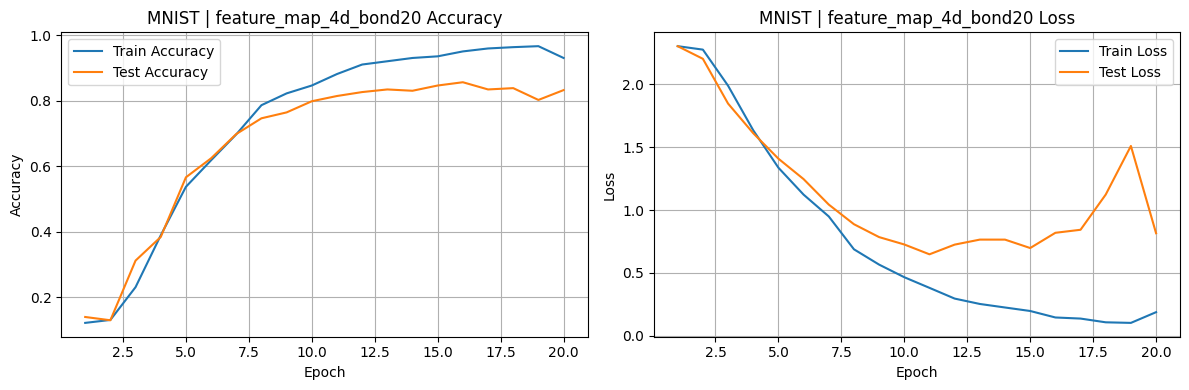

In [56]:
mnist_results = {}

for exp in experiments:
    model, history = train_one_experiment(
        dataset_name="mnist",
        exp_name=exp["name"],
        bond_dim=exp["bond_dim"],
        feature_dim=exp["feature_dim"],
        feature_map=exp["feature_map"],
    )
    mnist_results[exp["name"]] = {
        "model": model,
        "history": history,
    }
    plot_history(history, title_prefix=f"MNIST | {exp['name']}")

# FashionMNIST experiments


===== fashionmnist | no_feature_map_bond20 =====


100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:01<00:00, 14.8MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 1.94MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:00<00:00, 13.6MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 31.4MB/s]


Epoch 01/20 | train loss: 2.3026, train acc: 0.1300 | test loss: 2.3024, test acc: 0.1780
Epoch 02/20 | train loss: 2.2947, train acc: 0.2110 | test loss: 2.2463, test acc: 0.1040
Epoch 03/20 | train loss: 2.0338, train acc: 0.1840 | test loss: 1.8123, test acc: 0.2260
Epoch 04/20 | train loss: 1.6728, train acc: 0.2920 | test loss: 1.5474, test acc: 0.3840
Epoch 05/20 | train loss: 1.4048, train acc: 0.4180 | test loss: 1.3046, test acc: 0.4120
Epoch 06/20 | train loss: 1.1861, train acc: 0.5130 | test loss: 1.0656, test acc: 0.5900
Epoch 07/20 | train loss: 1.0281, train acc: 0.6040 | test loss: 0.9524, test acc: 0.6260
Epoch 08/20 | train loss: 0.9781, train acc: 0.6150 | test loss: 0.9257, test acc: 0.5860
Epoch 09/20 | train loss: 0.9132, train acc: 0.6390 | test loss: 0.8294, test acc: 0.6760
Epoch 10/20 | train loss: 0.8607, train acc: 0.6750 | test loss: 0.8111, test acc: 0.6460
Epoch 11/20 | train loss: 0.7993, train acc: 0.6880 | test loss: 0.7857, test acc: 0.6940
Epoch 12/2

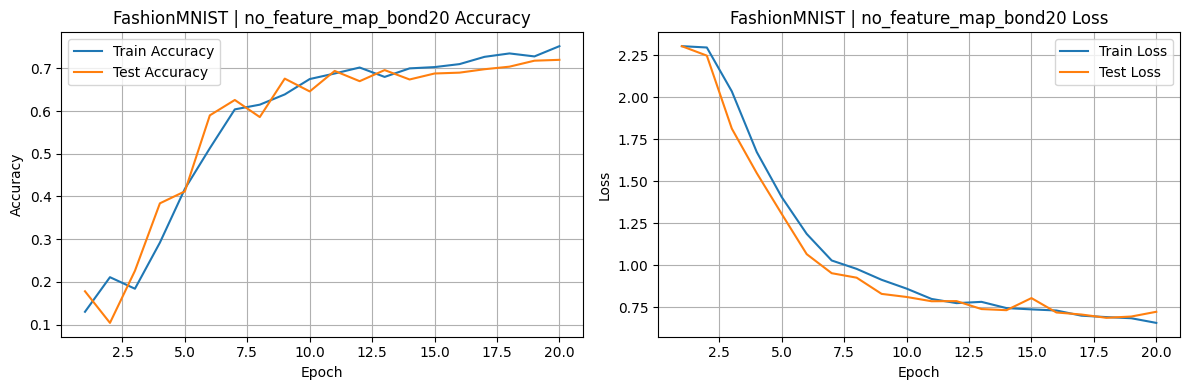


===== fashionmnist | feature_map_2d_bond10 =====
Epoch 01/20 | train loss: 2.3026, train acc: 0.1260 | test loss: 2.3025, test acc: 0.1420
Epoch 02/20 | train loss: 2.3013, train acc: 0.1790 | test loss: 2.2966, test acc: 0.1520
Epoch 03/20 | train loss: 2.2292, train acc: 0.1960 | test loss: 1.9879, test acc: 0.1660
Epoch 04/20 | train loss: 1.8074, train acc: 0.2100 | test loss: 1.7409, test acc: 0.2300
Epoch 05/20 | train loss: 1.6605, train acc: 0.2200 | test loss: 1.6144, test acc: 0.1900
Epoch 06/20 | train loss: 1.4921, train acc: 0.3100 | test loss: 1.3805, test acc: 0.4240
Epoch 07/20 | train loss: 1.3199, train acc: 0.4320 | test loss: 1.2671, test acc: 0.4480
Epoch 08/20 | train loss: 1.2104, train acc: 0.4760 | test loss: 1.1566, test acc: 0.5320
Epoch 09/20 | train loss: 1.1607, train acc: 0.5400 | test loss: 1.0488, test acc: 0.5720
Epoch 10/20 | train loss: 1.0486, train acc: 0.5810 | test loss: 1.0192, test acc: 0.5920
Epoch 11/20 | train loss: 1.0187, train acc: 0.593

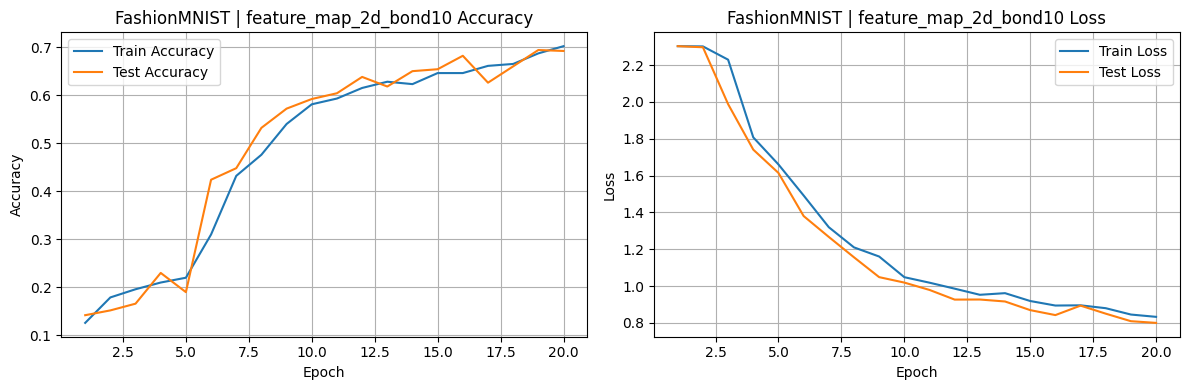


===== fashionmnist | feature_map_2d_bond20 =====
Epoch 01/20 | train loss: 2.3026, train acc: 0.1300 | test loss: 2.3023, test acc: 0.1920
Epoch 02/20 | train loss: 2.2872, train acc: 0.1950 | test loss: 2.1896, test acc: 0.1080
Epoch 03/20 | train loss: 1.9313, train acc: 0.2090 | test loss: 1.7884, test acc: 0.3180
Epoch 04/20 | train loss: 1.6433, train acc: 0.3070 | test loss: 1.4946, test acc: 0.3900
Epoch 05/20 | train loss: 1.4347, train acc: 0.4020 | test loss: 1.3619, test acc: 0.4780
Epoch 06/20 | train loss: 1.2999, train acc: 0.4740 | test loss: 1.2016, test acc: 0.5220
Epoch 07/20 | train loss: 1.1428, train acc: 0.5300 | test loss: 1.0805, test acc: 0.6000
Epoch 08/20 | train loss: 1.0618, train acc: 0.5570 | test loss: 1.0172, test acc: 0.5980
Epoch 09/20 | train loss: 1.0155, train acc: 0.5870 | test loss: 0.9808, test acc: 0.5940
Epoch 10/20 | train loss: 1.0099, train acc: 0.5950 | test loss: 0.9804, test acc: 0.5840
Epoch 11/20 | train loss: 0.9421, train acc: 0.618

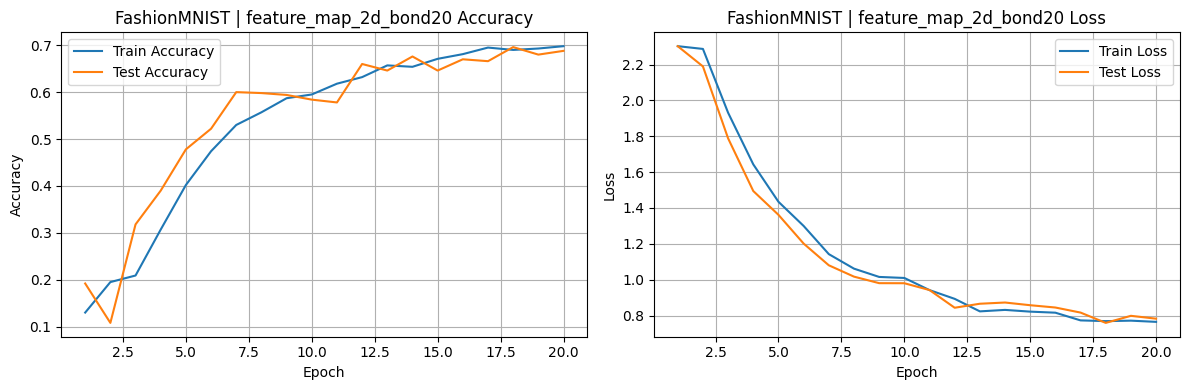


===== fashionmnist | feature_map_4d_bond20 =====
Epoch 01/20 | train loss: 2.3021, train acc: 0.1370 | test loss: 2.2938, test acc: 0.1300
Epoch 02/20 | train loss: 2.1265, train acc: 0.1620 | test loss: 1.8655, test acc: 0.1860
Epoch 03/20 | train loss: 1.8368, train acc: 0.3240 | test loss: 1.6929, test acc: 0.3720
Epoch 04/20 | train loss: 1.6203, train acc: 0.3780 | test loss: 1.3757, test acc: 0.4240
Epoch 05/20 | train loss: 1.2680, train acc: 0.4750 | test loss: 1.1698, test acc: 0.5040
Epoch 06/20 | train loss: 1.0282, train acc: 0.5750 | test loss: 0.9191, test acc: 0.6240
Epoch 07/20 | train loss: 0.9051, train acc: 0.6300 | test loss: 0.8692, test acc: 0.6600
Epoch 08/20 | train loss: 0.7888, train acc: 0.6910 | test loss: 0.7683, test acc: 0.6980
Epoch 09/20 | train loss: 0.7319, train acc: 0.7240 | test loss: 0.7198, test acc: 0.7100
Epoch 10/20 | train loss: 0.6896, train acc: 0.7260 | test loss: 0.6946, test acc: 0.7100
Epoch 11/20 | train loss: 0.6553, train acc: 0.735

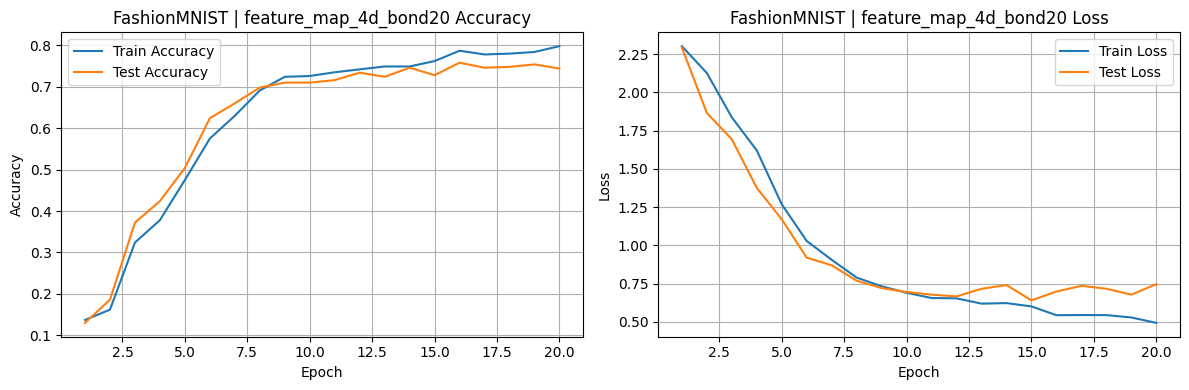

In [57]:
fashion_results = {}

for exp in experiments:
    model, history = train_one_experiment(
        dataset_name="fashionmnist",
        exp_name=exp["name"],
        bond_dim=exp["bond_dim"],
        feature_dim=exp["feature_dim"],
        feature_map=exp["feature_map"],
    )
    fashion_results[exp["name"]] = {
        "model": model,
        "history": history,
    }
    plot_history(history, title_prefix=f"FashionMNIST | {exp['name']}")

# summary

In [58]:
def summarize_results(results_dict, dataset_name):
    print(f"\n===== FINAL SUMMARY: {dataset_name} =====")
    for exp_name, result in results_dict.items():
        h = result["history"]
        print(
            f"{exp_name:25s} | "
            f"final train acc: {h['train_acc'][-1]:.4f} | "
            f"final test acc: {h['test_acc'][-1]:.4f} | "
            f"final train loss: {h['train_loss'][-1]:.4f} | "
            f"final test loss: {h['test_loss'][-1]:.4f}"
        )

summarize_results(mnist_results, "MNIST")
summarize_results(fashion_results, "FashionMNIST")


===== FINAL SUMMARY: MNIST =====
no_feature_map_bond20     | final train acc: 0.7950 | final test acc: 0.7780 | final train loss: 0.5795 | final test loss: 0.7450
feature_map_2d_bond10     | final train acc: 0.7890 | final test acc: 0.7700 | final train loss: 0.6802 | final test loss: 0.7546
feature_map_2d_bond20     | final train acc: 0.7640 | final test acc: 0.7400 | final train loss: 0.7018 | final test loss: 0.8660
feature_map_4d_bond20     | final train acc: 0.9300 | final test acc: 0.8320 | final train loss: 0.1886 | final test loss: 0.8158

===== FINAL SUMMARY: FashionMNIST =====
no_feature_map_bond20     | final train acc: 0.7520 | final test acc: 0.7200 | final train loss: 0.6569 | final test loss: 0.7230
feature_map_2d_bond10     | final train acc: 0.7020 | final test acc: 0.6920 | final train loss: 0.8333 | final test loss: 0.8005
feature_map_2d_bond20     | final train acc: 0.6980 | final test acc: 0.6880 | final train loss: 0.7649 | final test loss: 0.7828
feature_map_4d_

## Final Results — MNIST

| Experiment                | Train Acc | Test Acc | Train Loss | Test Loss |
|--------------------------|----------:|---------:|-----------:|----------:|
| no_feature_map_bond20    | 0.7950    | 0.7780   | 0.5795     | 0.7450    |
| feature_map_2d_bond10    | 0.7890    | 0.7700   | 0.6802     | 0.7546    |
| feature_map_2d_bond20    | 0.7640    | 0.7400   | 0.7018     | 0.8660    |
| feature_map_4d_bond20    | **0.9300**    | **0.8320**   | **0.1886**     | **0.8158**    |

---

## Final Results — FashionMNIST

| Experiment                | Train Acc | Test Acc | Train Loss | Test Loss |
|--------------------------|----------:|---------:|-----------:|----------:|
| no_feature_map_bond20    | 0.7520    | 0.7200   | 0.6569     | 0.7230    |
| feature_map_2d_bond10    | 0.7020    | 0.6920   | 0.8333     | 0.8005    |
| feature_map_2d_bond20    | 0.6980    | 0.6880   | 0.7649     | 0.7828    |
| feature_map_4d_bond20    | **0.7980**    | **0.7440**  | **0.4926**| **0.7456**    |

# Some interesting observations

- Across both datasets the 4D feature map consistently achieves the test accuracy. This shows that using local embeddings is very important for improving the performance of MPS models. When the model maps each input pixel into a dimensional space it can capture more complex things in the data. This leads to results when classifying things.

- The 2D feature map does not do well. This is because it is not very good at showing the details of the input values. As a result the model has a time finding useful features. Even if we increase the bond dimension it does not completely make up for this limitation. This shows how important it is to design feature maps when working with MPS models.

- Something else that is important to note is that using dimensional feature maps can cause the model to overfit. We can see this clearly with the 4D feature map and a bond dimension of 20. The training accuracy becomes very high. The test accuracy does not improve as much. The loss curves also show this with a gap between the training and test loss. This means that while the model becomes very good at fitting the training data it does not generalize well.

- If we compare the two datasets MNIST always does better. Responds more to improvements in feature mapping. This is probably because MNIST is a dataset with more structure making it easier to find meaningful patterns. FashionMNIST is more complex. Has more variation making it harder for the model to improve just by changing the feature mapping.

- It is interesting that with the 2D feature map, a bond dimension of 10 does better than a larger one of 20 on both datasets. This suggests that increasing the bond dimension can cause overfitting or make it harder to optimize. The loss curves for the higher bond dimension support this as they show the training loss going down without improving the test performance. So using a bond dimension helps the model generalize better.

- The best configuration is the 4D feature map with a bond dimension of 20. However these results show that just increasing the bond dimension does not always mean performance. Instead the design of the feature map is more important. These findings show that when working with MPS models making the input representation better is often more effective, than increasing the model capacity especially when there is not a lot of data.